# XGBOOST Model Training


## Load Cleaned Data


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import modules
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

clean_train = pd.read_csv('data/clean_train.csv')
clean_val = pd.read_csv('data/clean_val.csv')

X_tr = clean_train.drop(columns=['target'])
y_tr = clean_train['target']
X_val = clean_val.drop(columns=['target'])
y_val = clean_val['target']


print('X_tr shape:', X_tr.shape)
print('X_val shape:', X_val.shape)
print('y_tr shape:', y_tr.shape)
print('y_val shape:', y_val.shape)


X_tr shape: (24546, 70)
X_val shape: (6011, 70)
y_tr shape: (24546,)
y_val shape: (6011,)


## Target Skewness


Skewness: 2.09


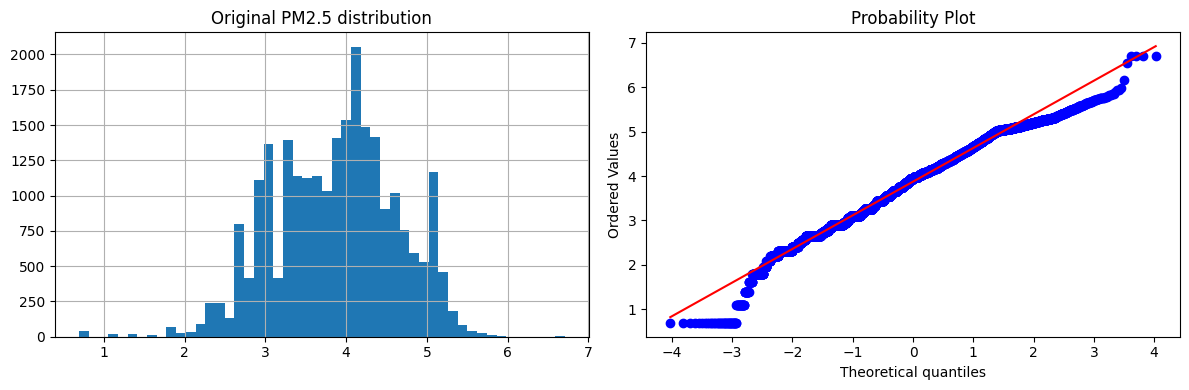

In [2]:
#Handle the target skewness by applying a log transform

import scipy.stats as stats

print(f"Skewness: {y_tr.skew():.2f}")



# Apply log transform
y_tr_log  = np.log1p(y_tr.reset_index(drop=True))
y_val_log = np.log1p(y_val.reset_index(drop=True))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y_tr_log.hist(bins=50, ax=axes[0])
axes[0].set_title("Original PM2.5 distribution")
stats.probplot(y_tr_log, plot=axes[1])
plt.tight_layout()
plt.show()


Top 25 features by XGBoost:
L3_HCHO_tropospheric_HCHO_column_number_density        0.101287
L3_AER_AI_sensor_altitude                              0.094543
L3_CO_CO_column_number_density                         0.073966
L3_NO2_NO2_column_number_density                       0.048104
L3_NO2_NO2_slant_column_number_density                 0.041079
u_component_of_wind_10m_above_ground                   0.023790
temperature_2m_above_ground                            0.023541
v_component_of_wind_10m_above_ground                   0.022038
L3_HCHO_tropospheric_HCHO_column_number_density_amf    0.020520
L3_CLOUD_cloud_top_pressure                            0.018005
L3_NO2_tropopause_pressure                             0.017711
specific_humidity_2m_above_ground                      0.017491
L3_NO2_sensor_altitude                                 0.016974
day_number                                             0.016283
L3_O3_solar_zenith_angle                               0.015687
L3_SO2_senso

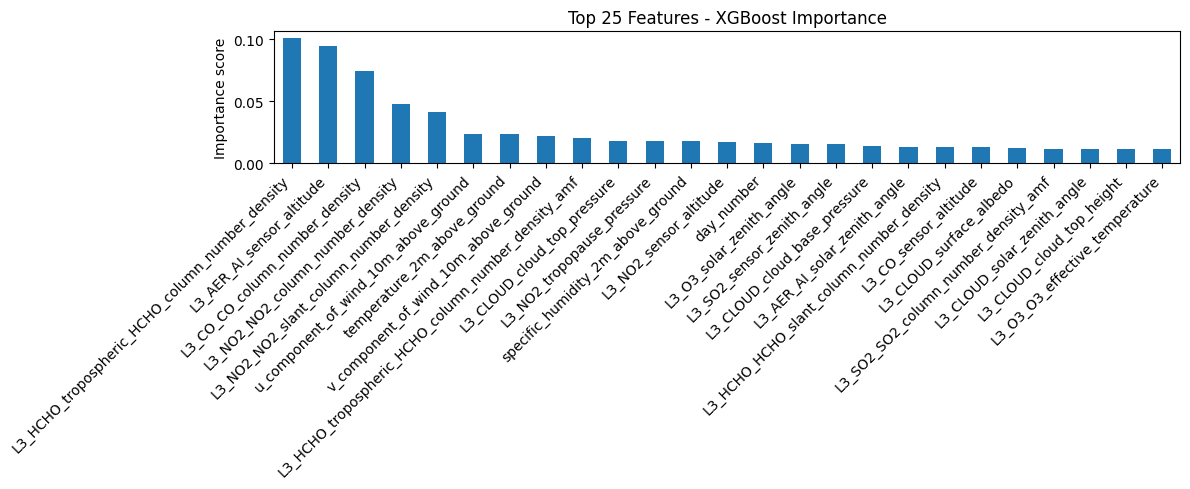

In [ ]:
#Use XGBoostRegressor to fit the train set and calculate the top 25 best features

xgb = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb.fit(X_tr, y_tr_log)

xgb_importance = pd.Series(xgb.feature_importance_, index=X_tr.columns)
xgb_importance = xgb_importance.sort_values(ascending=False)

print("Top 25 features by XGBoost:")
print(xgb_importance.head(25))

# Plot
xgb_importance.head(25).plot(kind='bar', figsize=(12, 5))
plt.title("Top 25 Features - XGBoost Importance")
plt.ylabel("Importance score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [13]:
# Predict and reverse log transform
y_val_pred_xgb = np.expm1(xgb.predict(X_val))

# Compute RMSE
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_val_pred_xgb))
print(f"XGBoost Validation RMSE: {rmse_xgb:.2f} µg/m³")

XGBoost Validation RMSE: 31.87 µg/m³


In [14]:
print(f"Random Forest RMSE: 32.03 µg/m³")
print(f"XGBoost RMSE:       {rmse_xgb:.2f} µg/m³")
print(f"Difference:         {32.03 - rmse_xgb:.2f} µg/m³")


Random Forest RMSE: 32.03 µg/m³
XGBoost RMSE:       31.87 µg/m³
Difference:         0.16 µg/m³


In [ ]:
#Hyperparameter tuning on XGBoost w/ RandomizedSearchCV for all features

param_grid = {
    'n_estimators':     [300, 500],
    'max_depth':        [9, 12],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3]
}

xgb = XGBRegressor(random_state=42, n_jobs=-1)
search = RandomizedSearchCV(xgb, param_grid, n_iter=30, 
                            cv=5, scoring='neg_root_mean_squared_error',
                            random_state=42, n_jobs=-1)
search.fit(X_tr, y_tr_log)

print("Best params:", search.best_params_)
print("Best CV RMSE:", -search.best_score_)


/Users/karina/neuefische_course/week-9/air_pollution_mlproject/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV RMSE: 0.5355035581358935


In [25]:
#Evaluate the best model on validation set:
best_xgb = search.best_estimator_
y_val_pred = np.expm1(best_xgb.predict(X_val))
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
print(f"Tuned XGBoost RMSE: {rmse:.2f} µg/m³")
print(f"Previous XGBoost RMSE: {rmse_xgb:.2f} µg/m³")


Tuned XGBoost RMSE: 29.32 µg/m³
Previous XGBoost RMSE: 31.87 µg/m³


In [ ]:
# XGBoost and RandomSearch with only 25 features and the same hyperparameters

# Step 1 — select top 25 features

xgb_importance = xgb_importance.sort_values(ascending=False).head(25).index.tolist()

X_tr_bf  = X_tr[xgb_importance]
X_val_bf = X_val[xgb_importance]

# Step 2 — define hyperparameter grid
param_grid = {
    'n_estimators':     [300, 500],
    'max_depth':        [9, 12],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3]
}

# Step 3 — run RandomizedSearchCV on training data only
xgb_bf = XGBRegressor(random_state=42, n_jobs=-1)
search_bf = RandomizedSearchCV(xgb_bf, param_grid, n_iter=30,
                            cv=5, scoring='neg_root_mean_squared_error',
                            random_state=42, n_jobs=-1, verbose=1)
search_bf.fit(X_tr_bf, y_tr_log)

print("Best params:", search.best_params_)

# Step 4 — evaluate best model on validation set
best_xgb_bf = search_bf.best_estimator_
y_val_pred_bf = np.expm1(best_xgb_bf.predict(X_val_bf))
rmse_tuned = np.sqrt(mean_squared_error(y_val, y_val_pred_bf))

print(f"Tuned XGBoost RMSE:   {rmse_tuned:.2f} µg/m³")
print(f"Baseline XGBoost RMSE: {rmse_xgb:.2f} µg/m³")
print(f"Improvement:           {rmse_xgb - rmse_tuned:.2f} µg/m³")


Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/karina/neuefische_course/week-9/air_pollution_mlproject/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Tuned XGBoost RMSE:   30.40 µg/m³
Baseline XGBoost RMSE: 31.87 µg/m³
Improvement:           1.46 µg/m³


In [31]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost (default)', 'XGBoost (tuned, all features)', 'XGBoost (tuned, 25 features)'],
    'RMSE':  [32.03,           31.87,               29.32,                          30.40]
})
results = results.sort_values('RMSE').reset_index(drop=True)
print(results.to_string(index=False))


                        Model  RMSE
XGBoost (tuned, all features) 29.32
 XGBoost (tuned, 25 features) 30.40
            XGBoost (default) 31.87
                Random Forest 32.03
